Este notebook se usa para graficar los resultados obtenidos de los diferentes experimentos llevados a cabo en el cluster NGPU.

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import matplotlib.pyplot as plt

Mounted at /content/drive


# ResNet18

## ResNet18 (25 epochs each model) + CIFAR10 (augmented)

Resultados obtenidos para la arquitectura similar a ResNet18 propuesta en "**arXiv:1912.02292**", donde se trabaja con un número de filtros de [k, 2k, 4k, 8k] en las distintas capas convolucionales de la red y donde para k=64 obtenemos la propia arquitectura ResNet18.

Como dataset se utiliza CIFAR10, al que se le aplican varias transformaciones para aumentar su tamaño, concretamente las propuestas en el paper anterior (RandomCrop y HorizontalFlip).

Se entrena cada modelo durante 25 épocas y se obtienen los siguientes resultados:

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Deep Double Descent/'
file1 = path + 'resnet18_train.txt'
file2 = path + 'resnet18_test.txt'

# Convertimos los archivos en dataframes de pandas
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# Mostramos los primeros datos para verificar que se han leído correctamente
print("Primeros datos del archivo 1:")
print(df1.head())

print("\nPrimeros datos del archivo 2:")
print(df2.head())

Primeros datos del archivo 1:
   model_dimension  epoch  train_loss  train_accuracy
0                1     25      2.0585          0.2184
1                2     25      1.8474          0.3171
2                3     25      1.7158          0.3614
3                4     25      1.6379          0.3951
4                5     25      1.5691          0.4223

Primeros datos del archivo 2:
   model_dimension  test_loss  test_accuracy
0                1     2.0177         0.2305
1                2     1.8061         0.3370
2                3     1.6400         0.3974
3                4     1.5733         0.4156
4                5     1.5016         0.4459


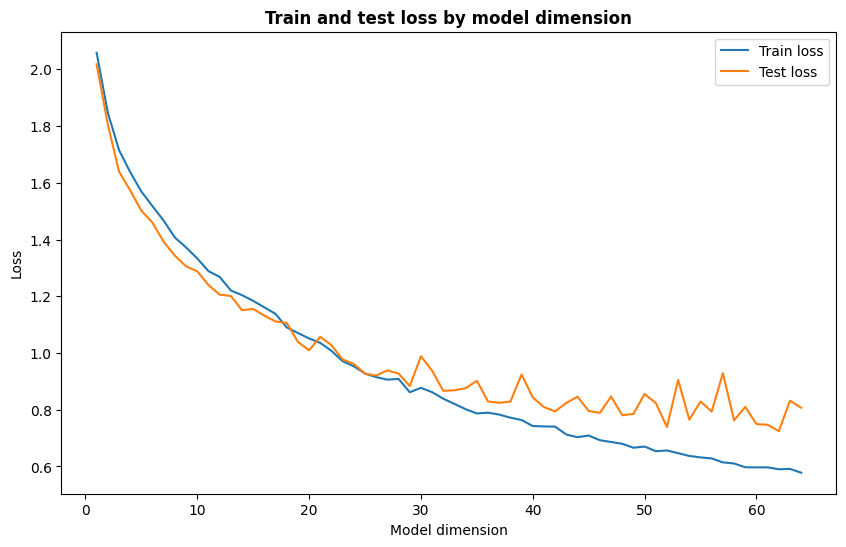

In [ ]:
# Unimos los dataFrames usando la columna común "model_dimension"
df = pd.merge(df1, df2, on="model_dimension")

# Creamos la gráfica del error de entrenamiento y test
plt.figure(figsize=(10, 6))
plt.plot(df["model_dimension"], df["train_loss"], label="Train loss")
plt.plot(df["model_dimension"], df["test_loss"], label="Test loss")

plt.xlabel("Model dimension")
plt.ylabel("Loss")
plt.title("Train and test loss by model dimension", fontweight="bold")
plt.legend()
plt.show()

Podemos observar como no se produce el fenómeno del double descent, pues el error en test va progresivamente decreciendo (aunque no lo haga de manera monótona).

**Cabe destacar que el error de entrenamiento no ha convergido todavía a valores cercanos a 0.**

<br>

## ResNet18 (25 epochs + 20% output noise) + CIFAR10 (augmented)

Resultados obtenidos para la misma arquitectura definida en el apartado anterior con la salvedad de que introducimos un 20% de ruido a las etiquetas de entrenamiento.

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Deep Double Descent/'
file1 = path + 'resnet18_train_noise.txt'
file2 = path + 'resnet18_test_noise.txt'

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print("Primeros datos del archivo 1:")
print(df1.head())

print("\nPrimeros datos del archivo 2:")
print(df2.head())

Primeros datos del archivo 1:
   model_dimension  epoch  train_loss  train_accuracy
0                1     25      2.1849          0.1767
1                2     25      2.0553          0.2593
2                3     25      1.9785          0.2985
3                4     25      1.9407          0.3137
4                5     25      1.9041          0.3338

Primeros datos del archivo 2:
   model_dimension  test_loss  test_accuracy
0                1     2.0807         0.2105
1                2     1.8713         0.3241
2                3     1.7276         0.3828
3                4     1.6780         0.4032
4                5     1.6232         0.4233


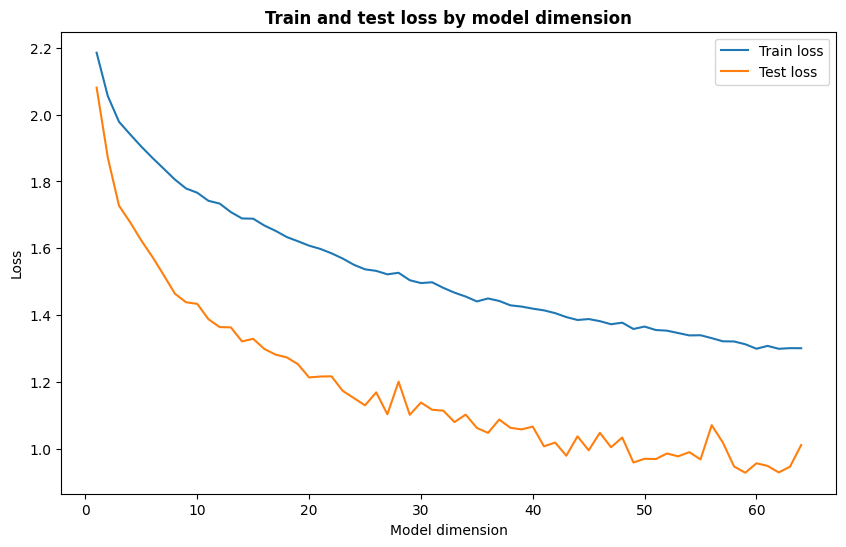

In [ ]:
df = pd.merge(df1, df2, on="model_dimension")

plt.figure(figsize=(10, 6))
plt.plot(df["model_dimension"], df["train_loss"], label="Train loss")
plt.plot(df["model_dimension"], df["test_loss"], label="Test loss")

plt.xlabel("Model dimension")
plt.ylabel("Loss")
plt.title("Train and test loss by model dimension", fontweight="bold")
plt.legend()
plt.show()

Nuevamente, podemos observar como agregando ruido en las etiquetas (20%) no se produce el fenómeno del double descent y, de hecho, se produce una situación anómala donde el error de test es siempre menor que el de entrenamiento (esto se podría producir porque los ejemplos de test son "más sencillos" que los de entrenamiento y el modelo los predice de manera más fácil). Además, este error de entrenamiento, al igual que en el apartado anterior, no ha convergido todavía a valores cercanos a 0.

<br>

### **Apéndice**

Este experimento fue realizado siguiendo el experimento que se ofrece en el paper "**arXiv:1912.02292**", en el que se obtienen los siguientes resultados:

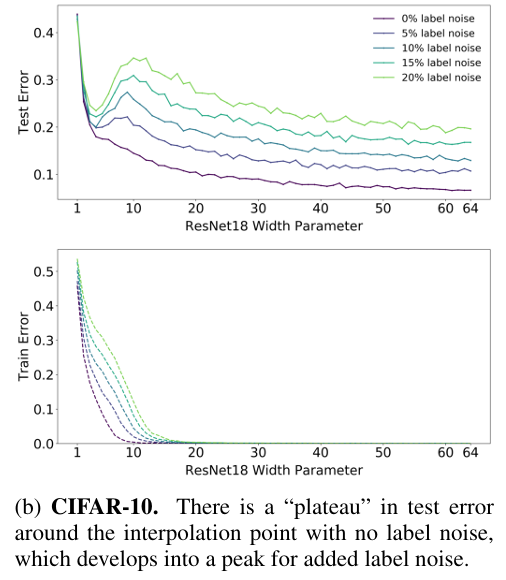

Donde podemos observar que se produce el fenómeno del double descent (bastante pronunciado) cuando trabajan con el dataset CIFAR10 al agregar un ruido del 20% a las etiquetas.

Sin embargo, en nuestro caso no hemos conseguido replicar este experimento. Esto viene del hecho de que 25 épocas no son suficientes para alcanzar un error de entrenamiento cercano a 0, como hemos podido observar en nuestros experimentos (pues aún con el último valor k=64 (arquitectura ResNet18) no conseguíamos un valor ni cercano a 0), mientras que en el experimento del paper citad podemos ver como alcanzan un error de entrenamiento de 0 en un valor cercano a k=10 (y, por tanto, en adelante), que será el umbral de interpolación donde se produce el pico del error de test, como podemos observar en la imagen superior.

\\

Este experimento fue realizado con los mismos parámetros que los citados en el paper, a excepción del número de épocas, donde el paper utiliza 4000 épocas para cada modelo, mientras que yo utilicé únicamente 25 épocas, debido al tiempo necesario para entrenar cada modelo.

*Véanse los parámetros utilizados en una imagen del paper citado a continuación*:

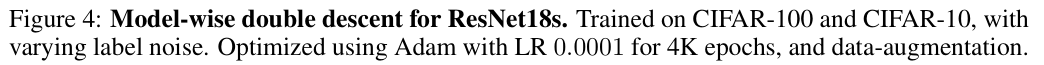

***La reducción del número de épocas para el entrenamiento de cada modelo se debe, como se ha comentado anteriormente, al tiempo requerido para el entrenamiento de los modelos. Como dato adicional, el tiempo necesario para entrenar durante 25 épocas cada modelo (64 modelos) fue de 10h y 25min, lo que muestra la dificultad de replicar exactamente este experimento.***

<br>

# 2NN (2 dense layer)

## 2NN (1000 epochs) + MNIST (4k training samples)

Resultados obtenidos para la arquitectura 2NN (2 capas densas/totalmente conectadas) sobre la que vamos aumentando el número de unidades (neuronas) de la primera capa oculta, desde 1 unidad hasta 100.

Como dataset se utiliza MNIST, del que tomamos un subconjunto del mismo para el entrenamiento y test. En concreto, se usan 4000 ejemplos para entrenamiento y 1000 para test.

Se entrena cada modelo durante 1000 épocas y se obtienen los siguientes resultados:

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Deep Double Descent/'
file1 = path + 'mnist_train.txt'
file2 = path + 'mnist_test.txt'

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print("Primeros datos del archivo 1:")
print(df1.head())

print("\nPrimeros datos del archivo 2:")
print(df2.head())

Primeros datos del archivo 1:
   units  epoch  train_loss  train_accuracy
0      1   1000    1.749386         0.32325
1      2   1000    1.327016         0.56500
2      3   1000    0.992825         0.71800
3      4   1000    0.934157         0.75450
4      5   1000    0.701110         0.82375

Primeros datos del archivo 2:
   units  test_loss  test_accuracy
0      1   1.704922          0.316
1      2   1.233714          0.569
2      3   1.048983          0.680
3      4   0.853109          0.719
4      5   0.881513          0.763


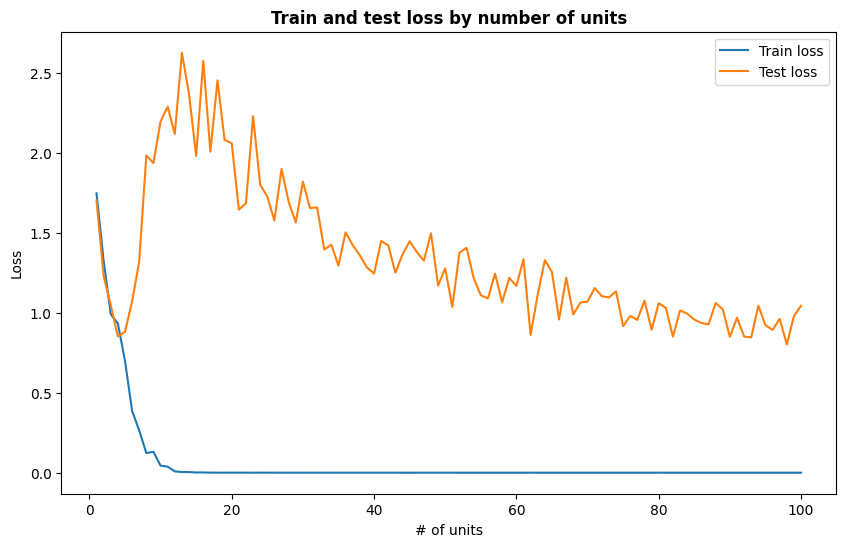

In [ ]:
# Unimos los dataFrames usando la columna común "units"
df = pd.merge(df1, df2, on="units")

plt.figure(figsize=(10, 6))
plt.plot(df["units"], df["train_loss"], label="Train loss")
plt.plot(df["units"], df["test_loss"], label="Test loss")

plt.xlabel("# of units")
plt.ylabel("Loss")
plt.title("Train and test loss by number of units", fontweight="bold")
plt.legend()
plt.show()

En este caso sí podemos observar la aparición del double descent con un pico del error de test en torno a 10 unidades en la primera capa (umbral de interpolación).

**Cabe destacar que este experimento es similar al realizado usando *keras* con la salvedad de que aquí se utiliza PyTorch. Como dato adicional, el tiempo necesario para realizar este experimento fue de 26h.**

<br>

## 2NN (1000 epochs) + MNIST (8k training samples)

Resultados obtenidos para la misma arquitectura definida en el apartado anterior con la salvedad de que utilizamos el doble de ejemplos para el entrenamiento (8000 ejemplos).

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Deep Double Descent/'
file1 = path + 'mnist_train8k.txt'
file2 = path + 'mnist_test8k.txt'

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print("Primeros datos del archivo 1:")
print(df1.head())

print("\nPrimeros datos del archivo 2:")
print(df2.head())

Primeros datos del archivo 1:
   units  epoch  train_loss  train_accuracy
0      1   1000    1.779498        0.362500
1      2   1000    1.337581        0.618875
2      3   1000    1.050363        0.734125
3      4   1000    1.033920        0.729500
4      5   1000    0.870078        0.779500

Primeros datos del archivo 2:
   units  test_loss  test_accuracy
0      1   1.626092          0.379
1      2   1.139819          0.634
2      3   0.863235          0.731
3      4   0.765043          0.762
4      5   0.729473          0.777


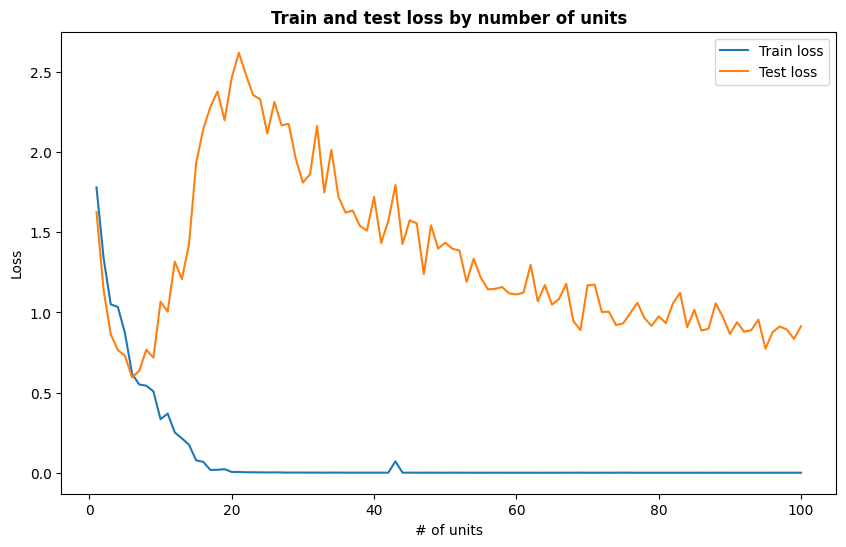

In [ ]:
df = pd.merge(df1, df2, on="units")

plt.figure(figsize=(10, 6))
plt.plot(df["units"], df["train_loss"], label="Train loss")
plt.plot(df["units"], df["test_loss"], label="Test loss")

plt.xlabel("# of units")
plt.ylabel("Loss")
plt.title("Train and test loss by number of units", fontweight="bold")
plt.legend()
plt.show()

Observamos, nuevamente, la aparición del double descent. No obstante, cabe destacar que el aumento del número de ejemplos de entrenamiento mueve el pico del error de test (umbral de interpolación) hacia la derecha, como era de esperar, pues son necesarios una mayor cantidad de parámetros (en este caso el doble, pues usamos el doble de ejemplos de entrenamiento) para alcanzar el error de entrenamiento 0.

**Como dato adicional, el tiempo necesario para este experimento fue de 59h.**

<br>

## 2NN (4k samples) test error vs 2NN (8k samples) test error

Comparación del error de test para los dos modelos definidos anteriormente:
- 2NN entrenado con 4000 ejemplos.
- 2NN entrenado con 8000 ejemplos.

In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/Deep Double Descent/'
file1 = path + 'mnist_test.txt'
file2 = path + 'mnist_test8k.txt'

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print("Primeros datos del archivo 1:")
print(df1.head())

print("\nPrimeros datos del archivo 2:")
print(df2.head())

Primeros datos del archivo 1:
   units  test_loss  test_accuracy
0      1   1.704922          0.316
1      2   1.233714          0.569
2      3   1.048983          0.680
3      4   0.853109          0.719
4      5   0.881513          0.763

Primeros datos del archivo 2:
   units  test_loss  test_accuracy
0      1   1.626092          0.379
1      2   1.139819          0.634
2      3   0.863235          0.731
3      4   0.765043          0.762
4      5   0.729473          0.777


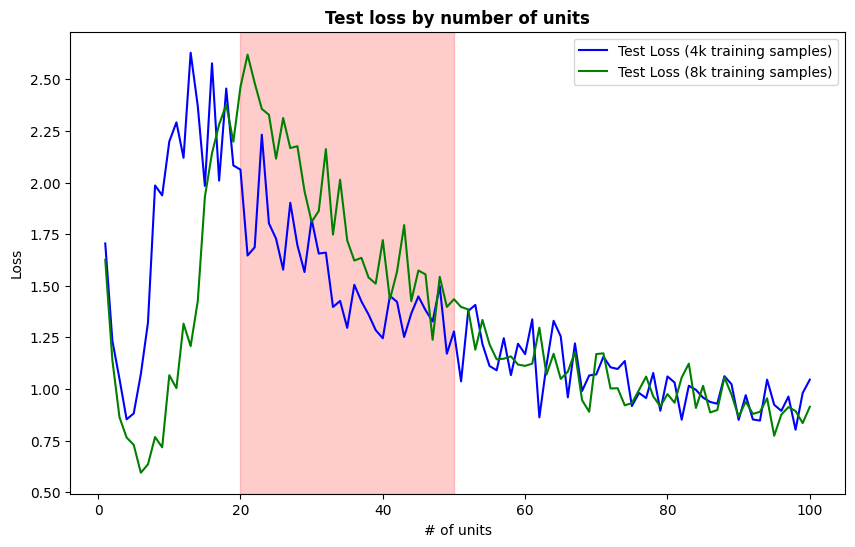

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(df1["units"], df1["test_loss"], label="Test Loss (4k training samples)", color="blue")
plt.plot(df2["units"], df2["test_loss"], label="Test Loss (8k training samples)", color="green")

plt.axvspan(20, 50, color="red", alpha=0.2)

plt.xlabel("# of units")
plt.ylabel("Loss")
plt.title("Test loss by number of units", fontweight="bold")

plt.legend()
plt.show()

Finalmente, y a modo de un ejemplo de "sample-wise non monotonicity", podemos comparar las gráficas de test de los dos modelos 2NN descritos anteriormente. Podemos observar como hay una región (en torno al número de unidades desde 20 hasta 50) donde entrenar con más ejemplos es peor.

Esto se debe a que, como al entrenar con más ejemplos movemos el pico hacia la derecha, pueden darse estas situaciones donde el modelo entrenado con menos ejemplos de mejores resultados. No obstante, destacar que, a medida que avanzamos en la dimensión del modelo, el modelo entrenado con más ejemplos parece descender de una manera más rápida en el error de test.

**Como dato adicional en esta sección, quizás sería más útil y realista realizar este experimento utilizando distintos subconjuntos de entrenamiento y test para entrenar, de manera que para la gráfica del error en test se tome la media de los distintos errores para los distintos subconjuntos de datos utilizados, resultando en una gráfica más "suave" y sin la aparición de tantos "picos".**